In [32]:
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Original images

In [42]:
ORIGINAL_IMAGES_FILEPATH = "/run/media/gianluca/Hard_drive/dataset_FSM_v1"
PATIENT_NAME = "FSM_032_MR_1_anon"

t1w_filepath = f"{ORIGINAL_IMAGES_FILEPATH}/{PATIENT_NAME}/COREGISTERED/FSM_032_T1_original.nii.gz"
flair_filepath = f"{ORIGINAL_IMAGES_FILEPATH}/{PATIENT_NAME}/COREGISTERED/FSM_032_FLAIR_original.nii.gz"

roi1_filepath = f"{ORIGINAL_IMAGES_FILEPATH}/{PATIENT_NAME}/COREGISTERED/ROI_1.nii"
roi2_filepath = f"{ORIGINAL_IMAGES_FILEPATH}/{PATIENT_NAME}/COREGISTERED/ROI_2.nii"
roi3_filepath = f"{ORIGINAL_IMAGES_FILEPATH}/{PATIENT_NAME}/COREGISTERED/ROI_3.nii"
roi4_filepath = f"{ORIGINAL_IMAGES_FILEPATH}/{PATIENT_NAME}/COREGISTERED/ROI_4.nii"

t1w_nib = nib.load(t1w_filepath)
flair_nib = nib.load(flair_filepath)
roi1_nib = nib.load(roi1_filepath)
roi2_nib = nib.load(roi2_filepath)
roi3_nib = nib.load(roi3_filepath)
roi4_nib = nib.load(roi4_filepath)

t1w_array = t1w_nib.get_fdata()
flair_array = flair_nib.get_fdata()
roi1_array = roi1_nib.get_fdata()
roi2_array = roi2_nib.get_fdata()
roi3_array = roi3_nib.get_fdata()
roi4_array = roi4_nib.get_fdata()

(np.float64(-0.5), np.float64(511.5), np.float64(153.5), np.float64(-0.5))

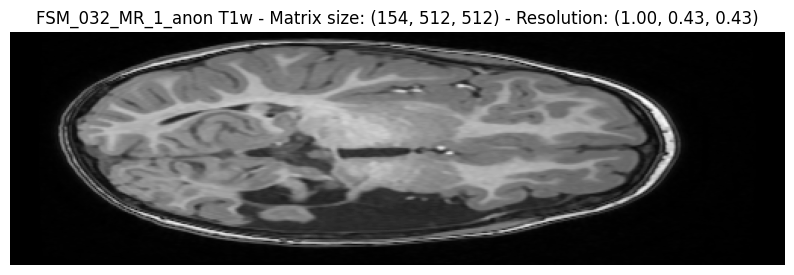

In [66]:
# getting voxel sizes
sx, sy, sz = t1w_nib.header.get_zooms()[:3]
voxel_size = f"({sx :.2f}, {sy :.2f}, {sz :.2f})"

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ax.imshow(t1w_array[:,:,256], cmap=plt.cm.grey)
ax.set_title(f"{PATIENT_NAME} T1w - Matrix size: {t1w_array.shape} - Resolution: {voxel_size}", fontsize=12)
ax.axis("off")

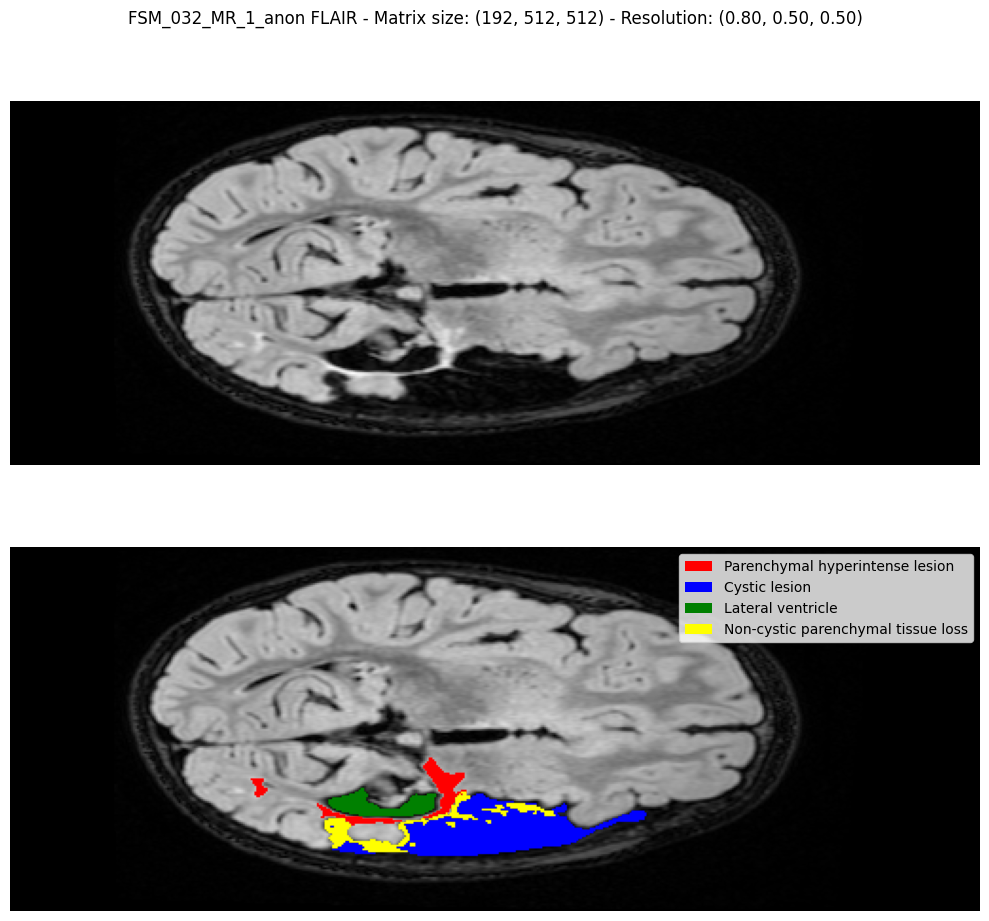

In [67]:
# getting voxel sizes
sx, sy, sz = flair_nib.header.get_zooms()[:3]
voxel_size = f"({sx :.2f}, {sy :.2f}, {sz :.2f})"

fig, axes = plt.subplots(2, 1, figsize=(10,10))
fig.suptitle(f"{PATIENT_NAME} FLAIR - Matrix size: {flair_array.shape} - Resolution: {voxel_size}", fontsize=12)

# define colors
colors = ["red", "blue", "green", "yellow"]
roi_arrays = [roi1_array, roi2_array, roi3_array, roi4_array]
roi_names = [
    "Parenchymal hyperintense lesion",
    "Cystic lesion",
    "Lateral ventricle",
    "Non-cystic parenchymal tissue loss"
]

axes[0].imshow(flair_array[:,:,256], cmap=plt.cm.grey)
axes[0].axis("off")

axes[1].imshow(flair_array[:,:,256], cmap=plt.cm.grey)
for roi, color in zip(roi_arrays, colors):
    mask = roi[:, :, 256]

    # create and RGBA image for the mask
    overlay = np.zeros((*mask.shape, 4))
    overlay[..., :3] = plt.matplotlib.colors.to_rgb(color)
    overlay[..., 3] = mask.astype(float)
    axes[1].imshow(overlay)

axes[1].axis("off")

# Legend
legend_elements = [
    Patch(facecolor=color, edgecolor='none', label=name)
    for color, name in zip(colors, roi_names)
]

axes[1].legend(
    handles=legend_elements,
    loc='upper right'
)

plt.tight_layout()
plt.show()

# Registered images

In [69]:
PREPROCESSED_IMAGES_FILEPATH = "/run/media/gianluca/Hard_drive/dataset_FSM_v1_preprocessed"
PATIENT_NAME = "FSM_032_MR_1_anon"

t1w_filepath = f"{PREPROCESSED_IMAGES_FILEPATH}/{PATIENT_NAME}/T1/T1_MNI.nii.gz"
flair_filepath = f"{PREPROCESSED_IMAGES_FILEPATH}/{PATIENT_NAME}/FLAIR/FLAIR_MNI.nii.gz"

roi1_filepath = f"{PREPROCESSED_IMAGES_FILEPATH}/{PATIENT_NAME}/ROI_1_MNI.nii.gz"
roi2_filepath = f"{PREPROCESSED_IMAGES_FILEPATH}/{PATIENT_NAME}/ROI_2_MNI.nii.gz"
roi3_filepath = f"{PREPROCESSED_IMAGES_FILEPATH}/{PATIENT_NAME}/ROI_3_MNI.nii.gz"
roi4_filepath = f"{PREPROCESSED_IMAGES_FILEPATH}/{PATIENT_NAME}/ROI_4_MNI.nii.gz"

t1w_nib = nib.load(t1w_filepath)
flair_nib = nib.load(flair_filepath)
roi1_nib = nib.load(roi1_filepath)
roi2_nib = nib.load(roi2_filepath)
roi3_nib = nib.load(roi3_filepath)
roi4_nib = nib.load(roi4_filepath)

t1w_array = t1w_nib.get_fdata()
flair_array = flair_nib.get_fdata()
roi1_array = roi1_nib.get_fdata()
roi2_array = roi2_nib.get_fdata()
roi3_array = roi3_nib.get_fdata()
roi4_array = roi4_nib.get_fdata()

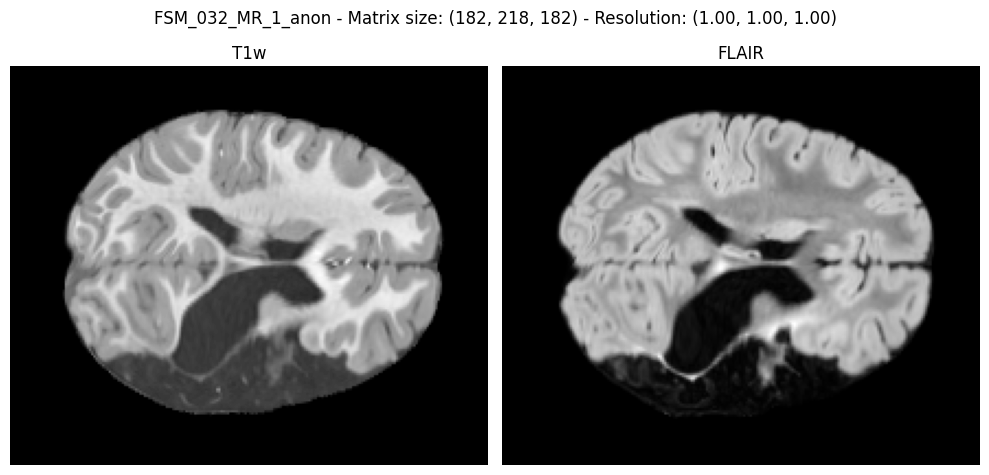

In [79]:
# getting voxel sizes
sx, sy, sz = t1w_nib.header.get_zooms()[:3]
voxel_size = f"({sx :.2f}, {sy :.2f}, {sz :.2f})"

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(t1w_array[:,:,91], cmap=plt.cm.grey)
axes[0].axis("off")
axes[0].set_title("T1w")

axes[1].imshow(flair_array[:,:,91], cmap=plt.cm.grey)
axes[1].axis("off")
axes[1].set_title("FLAIR")

fig.suptitle(f"{PATIENT_NAME} - Matrix size: {t1w_array.shape} - Resolution: {voxel_size}", fontsize=12)

plt.tight_layout()
plt.show()

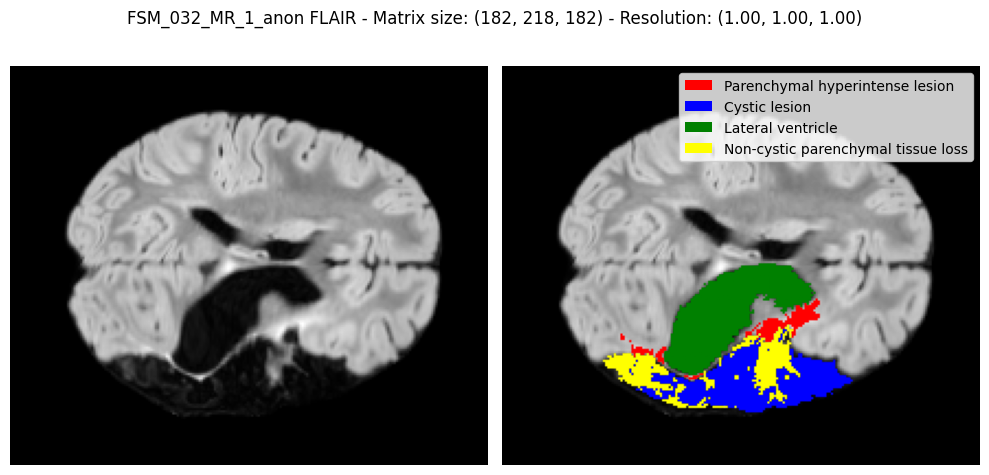

In [75]:
# getting voxel sizes
sx, sy, sz = flair_nib.header.get_zooms()[:3]
voxel_size = f"({sx :.2f}, {sy :.2f}, {sz :.2f})"

fig, axes = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle(f"{PATIENT_NAME} FLAIR - Matrix size: {flair_array.shape} - Resolution: {voxel_size}", fontsize=12)

# define colors
colors = ["red", "blue", "green", "yellow"]
roi_arrays = [roi1_array, roi2_array, roi3_array, roi4_array]
roi_names = [
    "Parenchymal hyperintense lesion",
    "Cystic lesion",
    "Lateral ventricle",
    "Non-cystic parenchymal tissue loss"
]

axes[0].imshow(flair_array[:,:,91], cmap=plt.cm.grey)
axes[0].axis("off")

axes[1].imshow(flair_array[:,:,91], cmap=plt.cm.grey)
for roi, color in zip(roi_arrays, colors):
    mask = roi[:, :, 91]

    # create and RGBA image for the mask
    overlay = np.zeros((*mask.shape, 4))
    overlay[..., :3] = plt.matplotlib.colors.to_rgb(color)
    overlay[..., 3] = mask.astype(float)
    axes[1].imshow(overlay)

axes[1].axis("off")

# Legend
legend_elements = [
    Patch(facecolor=color, edgecolor='none', label=name)
    for color, name in zip(colors, roi_names)
]

axes[1].legend(
    handles=legend_elements,
    loc='upper right'
)

plt.tight_layout()
plt.show()